In [1]:
import pandas as pd

In [2]:
# Load the CSV file into a DataFrame
df = pd.read_csv('finalNew.csv')

# View the first 5 rows
print(df.head())
df

       Date_x      Close       High        Low       Open     Volume  \
0  2023-05-01  28.818560  28.966092  27.692135  27.751944  570329000   
1  2023-06-01  39.644203  39.923316  38.218726  38.367253  635873000   
2  2023-07-03  42.283222  42.766739  42.072869  42.386904  198209000   
3  2023-08-01  46.364693  46.756492  45.886162  46.317836  237858000   
4  2023-09-01  48.360565  49.647615  47.994688  49.609733  463830000   

     Close_l    Close_2  Rolling_mean_3_x  Rolling_std_3_x  ...  return_y  \
0  27.661232  27.139885         27.873226         0.859182  ... -0.191382   
1  37.714336  39.984123         39.114221         1.224191  ...  0.144186   
2  42.172554  40.697086         41.717621         0.885539  ... -0.063589   
3  46.586018  46.606956         46.519222         0.134235  ... -0.126332   
4  49.203987  49.113262         48.892605         0.462987  ...  0.097744   

   Year_y  Month_y  Log_Close Log_Value boxcox_Close  Diff_Close  Diff_Value  \
0    2023        5   3.3

,Date_x,Close,High,Low,Open,Volume,Close_l,Close_2,Rolling_mean_3_x,Rolling_std_3_x,...,return_y,Year_y,Month_y,Log_Close,Log_Value,boxcox_Close,Diff_Close,Diff_Value,Seasonal_Diff_Close,Seasonal_Diff_Value
0,2023-05-01,28.818560,28.966092,27.692135,27.751944,570329000,27.661232,27.139885,27.873226,0.859182,...,-0.191382,2023,5,3.361020,2.297170,6.303270,0.942011,1.140,9.365526,-2.664
1,2023-06-01,39.644203,39.923316,38.218726,38.367253,635873000,37.714336,39.984123,39.114221,1.224191,...,0.144186,2023,6,3.679945,2.509599,7.366221,10.825644,2.354,21.399199,0.200
2,2023-07-03,42.283222,42.766739,42.072869,42.386904,198209000,42.172554,40.697086,41.717621,0.885539,...,-0.063589,2023,7,3.744390,2.374906,7.595449,2.639019,-1.550,27.816617,-0.050
3,2023-08-01,46.364693,46.756492,45.886162,46.317836,237858000,46.586018,46.606956,46.519222,0.134235,...,-0.126332,2023,8,3.836538,2.440606,7.932109,4.081470,0.730,27.995302,-0.040
4,2023-09-01,48.360565,49.647615,47.994688,49.609733,463830000,49.203987,49.113262,48.892605,0.462987,...,0.097744,2023,9,3.878685,2.575661,8.089660,1.995872,1.660,34.477687,-0.630
5,2023-10-02,44.648651,45.040479,43.730392,43.898888,433298000,43.369469,42.960697,43.659606,0.880586,...,-0.108712,2023,10,3.798824,2.482404,7.793038,-3.711914,-1.170,32.181533,0.280
6,2023-11-01,42.198971,42.254804,40.747305,40.762260,437593000,40.658569,41.038437,41.298659,0.802494,...,-0.021850,2023,11,3.742396,2.597491,7.588279,-2.449680,1.460,28.704551,2.370
7,2023-12-01,46.625744,47.059450,46.049466,46.386461,369317000,46.630733,47.996651,47.084376,0.790057,...,0.170503,2023,12,3.842153,2.619583,7.952966,4.426773,0.300,29.547842,2.270
8,2024-01-02,48.028790,49.152531,47.457447,49.101680,411254000,49.378883,49.378883,48.928852,0.779477,...,-0.041667,2024,1,3.871801,2.462150,8.063770,1.403046,-2.000,33.761492,2.727
9,2024-02-01,62.844852,63.008380,61.471833,61.920530,369146000,61.349186,62.592579,62.262206,0.800696,...,-0.148225,2024,2,4.140669,2.504709,9.121589,14.816063,0.510,41.971640,2.845


In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date_x               35 non-null     object 
 1   Close                35 non-null     float64
 2   High                 35 non-null     float64
 3   Low                  35 non-null     float64
 4   Open                 35 non-null     float64
 5   Volume               35 non-null     int64  
 6   Close_l              35 non-null     float64
 7   Close_2              35 non-null     float64
 8   Rolling_mean_3_x     35 non-null     float64
 9   Rolling_std_3_x      35 non-null     float64
 10  Spanding_mean_x      35 non-null     float64
 11  return_x             35 non-null     float64
 12  Year_x               35 non-null     int64  
 13  Month_x              35 non-null     int64  
 14  YM                   35 non-null     object 
 15  Date_y               35 non-null     objec

In [5]:
data = df[['return_x','Diff_Value']].dropna()
data

,return_x,Diff_Value
0,0.041839,1.140
1,0.051171,2.354
2,0.002624,-1.550
3,-0.004751,0.730
4,-0.017141,1.660
5,0.029495,-1.170
6,0.037886,1.460
7,-0.000107,0.300
8,-0.027342,-2.000
9,0.024380,0.510


In [6]:
# 2. Run the Granger Causality Test
# Format: [Response_Variable, Predictor_Variable]
# Here we test if "realgdp" (Col 2) Granger-causes "realcons" (Col 1)
max_lags = 5
results = grangercausalitytests(data[['return_x','Diff_Value']], maxlag=max_lags)

In [7]:
results

{1: ({'ssr_ftest': (1.385835917321637, 0.2480692345604084, 31.0, 1),
   'ssr_chi2test': (1.5199490706108276, 0.21762720054381404, 1),
   'lrtest': (1.4869546292521534, 0.22268956811524904, 1),
   'params_ftest': (1.3858359173216315, 0.2480692345604101, 31.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (1.621859507406737, 0.21554319257996096, 28.0, 2),
   'ssr_chi2test': (3.822954553173023, 0.14786179240921413, 2),
   'lrtest': (3.6172571912312605, 0.16387872677006873, 2),
   'params_ftest': (1.621859507406769, 0.2155431925799546, 28.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (1.0308195206716093, 0.3958959128728329, 25.0, 3),
   'ssr_chi2test': (3.95834695937898, 0.2659971754481902, 3),
   'lrtest': (3.732010780017248, 0.2918940787677424, 3),
   'params_ftest': (1.0308195206716562, 0.39589591287281206, 25.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0.,

In [8]:
# To inspect the p-values across all 4 tests for Lag 2:
lag = 2
for test_name, test_values in results[lag][0].items():
    p_value = test_values[1]
    print(f"Lag {lag} - {test_name} p-value: {p_value:.4f}")

Lag 2 - ssr_ftest p-value: 0.2155
Lag 2 - ssr_chi2test p-value: 0.1479
Lag 2 - lrtest p-value: 0.1639
Lag 2 - params_ftest p-value: 0.2155


## Interpretation:
• p ≤ 0.05: Reject the null hypothesis. This means the past values of your second column do have a statistically significant predictive impact on your first column.
• p > 0.05: Fail to reject the null hypothesis. There is no statistical evidence of Granger causality at that specific lag

In [9]:
# 2. Run the Granger Causality Test
# Format: [Response_Variable, Predictor_Variable]
# Here we test if "realgdp" (Col 2) Granger-causes "realcons" (Col 1)
max_lags = 5
results = grangercausalitytests(data[['Diff_Value','return_x']], maxlag=max_lags)

In [10]:
# To inspect the p-values across all 4 tests for Lag 2:
lag = 2
for test_name, test_values in results[lag][0].items():
    p_value = test_values[1]
    print(f"Lag {lag} - {test_name} p-value: {p_value:.4f}")

Lag 2 - ssr_ftest p-value: 0.9768
Lag 2 - ssr_chi2test p-value: 0.9727
Lag 2 - lrtest p-value: 0.9727
Lag 2 - params_ftest p-value: 0.9768


In [11]:
lag = 5
for test_name, test_values in results[lag][0].items():
    p_value = test_values[1]
    print(f"Lag {lag} - {test_name} p-value: {p_value:.4f}")

Lag 5 - ssr_ftest p-value: 0.8011
Lag 5 - ssr_chi2test p-value: 0.6039
Lag 5 - lrtest p-value: 0.6346
Lag 5 - params_ftest p-value: 0.8011


In [12]:
lag = 1
for test_name, test_values in results[lag][0].items():
    p_value = test_values[1]
    print(f"Lag {lag} - {test_name} p-value: {p_value:.4f}")

Lag 1 - ssr_ftest p-value: 0.9471
Lag 1 - ssr_chi2test p-value: 0.9441
Lag 1 - lrtest p-value: 0.9441
Lag 1 - params_ftest p-value: 0.9471


In [13]:
results

{1: ({'ssr_ftest': (0.004481045303266633, 0.9470588627148062, 31.0, 1),
   'ssr_chi2test': (0.004914694848744049, 0.9441101788993136, 1),
   'lrtest': (0.004914339673774748, 0.9441121951513137, 1),
   'params_ftest': (0.0044810453032649465, 0.9470588627148062, 31.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (0.023479947781116044, 0.9768127727075896, 28.0, 2),
   'ssr_chi2test': (0.05534559119834496, 0.9727065886131272, 2),
   'lrtest': (0.055299231896839274, 0.9727291358734541, 2),
   'params_ftest': (0.02347994778111305, 0.9768127727075927, 28.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.21392702713065517, 0.8857973745375955, 25.0, 3),
   'ssr_chi2test': (0.821479784181716, 0.8443227535863239, 3),
   'lrtest': (0.8111126311864041, 0.846807233894854, 3),
   'params_ftest': (0.21392702713065448, 0.8857973745375955, 25.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0.,

## VAR — Vector Autoregression Model

In [14]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

In [15]:
data = df[['return_x','Diff_Value']].dropna()
data

,return_x,Diff_Value
0,0.041839,1.140
1,0.051171,2.354
2,0.002624,-1.550
3,-0.004751,0.730
4,-0.017141,1.660
5,0.029495,-1.170
6,0.037886,1.460
7,-0.000107,0.300
8,-0.027342,-2.000
9,0.024380,0.510


In [16]:
model = VAR(data)

In [17]:
model

In [18]:
# 4. Select the optimal lag order (p) automatically based on AIC
lag_selection = model.select_order(maxlags=5)

In [19]:
lag_selection.summary()

,AIC,BIC,FPE,HQIC
0,-4.284,-4.191*,0.01379,-4.254
1,-4.177,-3.897,0.01536,-4.088
2,-4.365,-3.898,0.01280,-4.215
3,-4.518*,-3.864,0.01110*,-4.309*
4,-4.352,-3.512,0.01338,-4.083
5,-4.133,-3.106,0.01722,-3.804


In [20]:
optimal_lag = lag_selection.aic

In [21]:
optimal_lag

3

In [22]:
# 5. Fit the model
results = model.fit(optimal_lag)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 03, Oct, 2026
Time:                     21:43:14
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -4.00261
Nobs:                     32.0000    HQIC:                  -4.43131
Log likelihood:          -2.51012    FPE:                 0.00975964
AIC:                     -4.64387    Det(Omega_mle):      0.00657059
--------------------------------------------------------------------
Results for equation return_x
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                -0.007834         0.007557           -1.037           0.300
L1.return_x           0.455101         0.208217            2.186           0.029
L1.Diff_Value         0.004485         0.002701          

In [23]:
# 6. Forecast the next 5 steps
# The model requires the last 'p' values to make a forecast
lagged_values = data.values[-optimal_lag:]
forecast = results.forecast(y=lagged_values, steps=5)

In [24]:
forecast

array([[ 6.40825329e-02, -4.26058335e+00],
       [ 1.00611434e-02,  1.07977456e+01],
       [ 1.07336178e-02,  2.78681324e+00],
       [ 3.04869884e-02, -3.58847087e+00],
       [ 4.41849690e-03,  1.04778553e+01]])

In [25]:
# 7. Convert forecast back to dataframe
dates = pd.date_range(start="2026-01-01", periods=len(data), freq="M")
forecast_df = pd.DataFrame(forecast, index=pd.date_range(start=dates[-1] + pd.Timedelta(days=1), periods=5, freq="M"), columns=data.columns)
print(forecast_df)

            return_x  Diff_Value
2028-12-31  0.064083   -4.260583
2029-01-31  0.010061   10.797746
2029-02-28  0.010734    2.786813
2029-03-31  0.030487   -3.588471
2029-04-30  0.004418   10.477855


## Impulsive response irf

In [26]:
# 3. Compute the Impulse Response Function (IRF)
# 'periods' defines how many time steps into the future to track
irf = results.irf(periods=10)

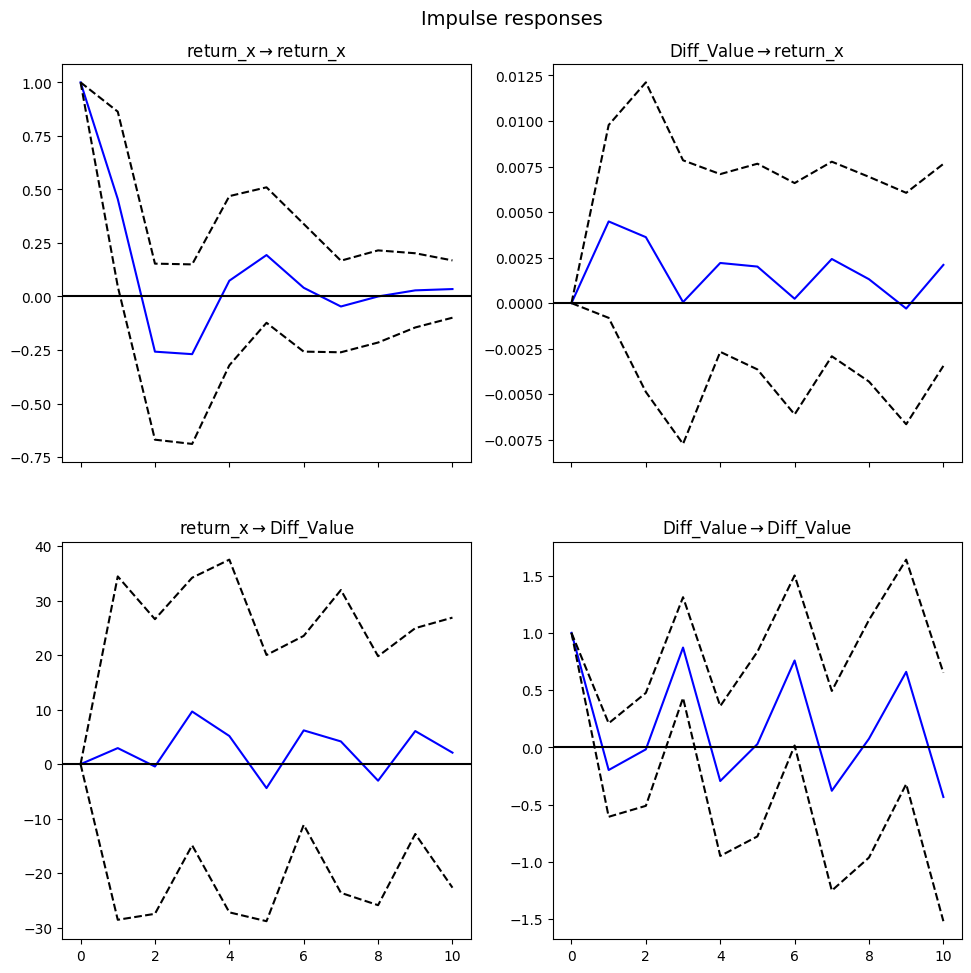

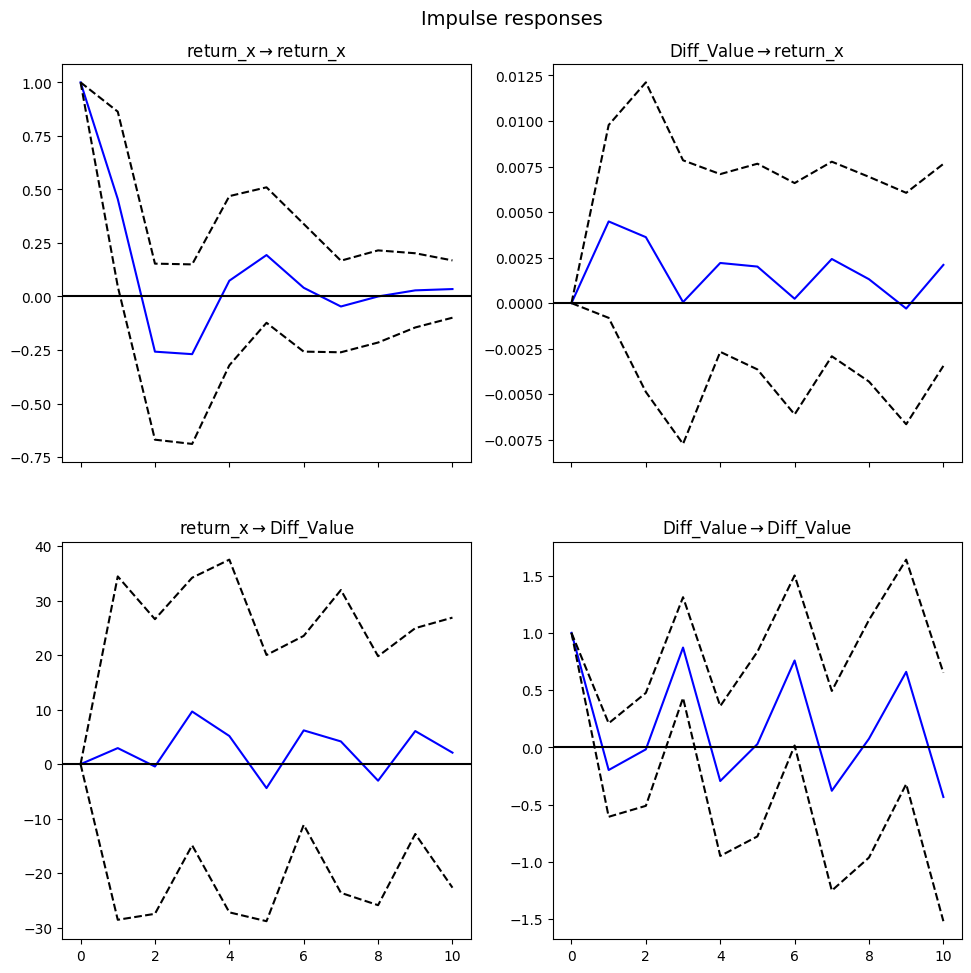

In [27]:
irf.plot()

## Forecasting error variance decomposition

In [28]:
fevd = results.fevd(periods=10)

FEVD for return_x
     return_x  Diff_Value
0    1.000000    0.000000
1    0.909451    0.090549
2    0.868861    0.131139
3    0.875218    0.124782
4    0.859649    0.140351
5    0.849515    0.150485
6    0.849466    0.150534
7    0.832835    0.167165
8    0.827932    0.172068
9    0.827797    0.172203

FEVD for Diff_Value
     return_x  Diff_Value
0    0.050094    0.949906
1    0.054506    0.945494
2    0.054492    0.945508
3    0.034903    0.965097
4    0.042476    0.957524
5    0.044501    0.955499
6    0.037639    0.962361
7    0.042837    0.957163
8    0.043910    0.956090
9    0.039398    0.960602


None


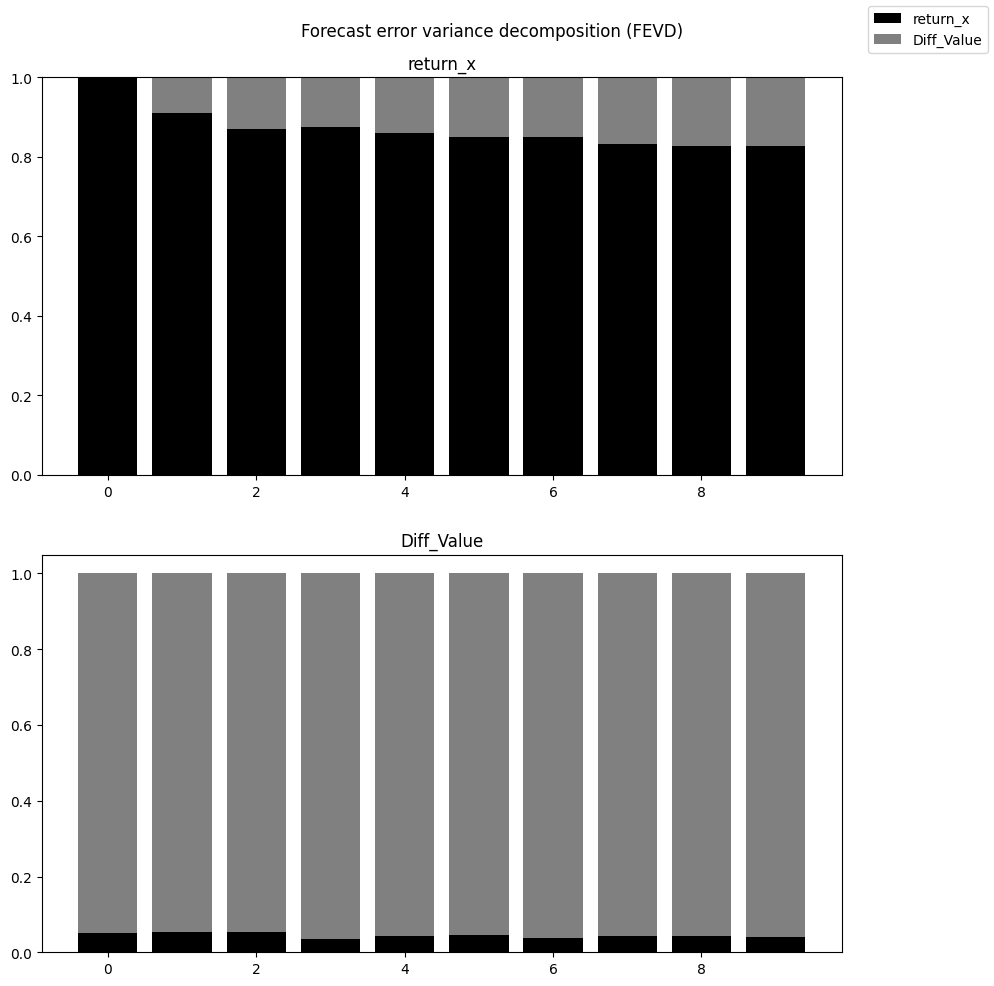

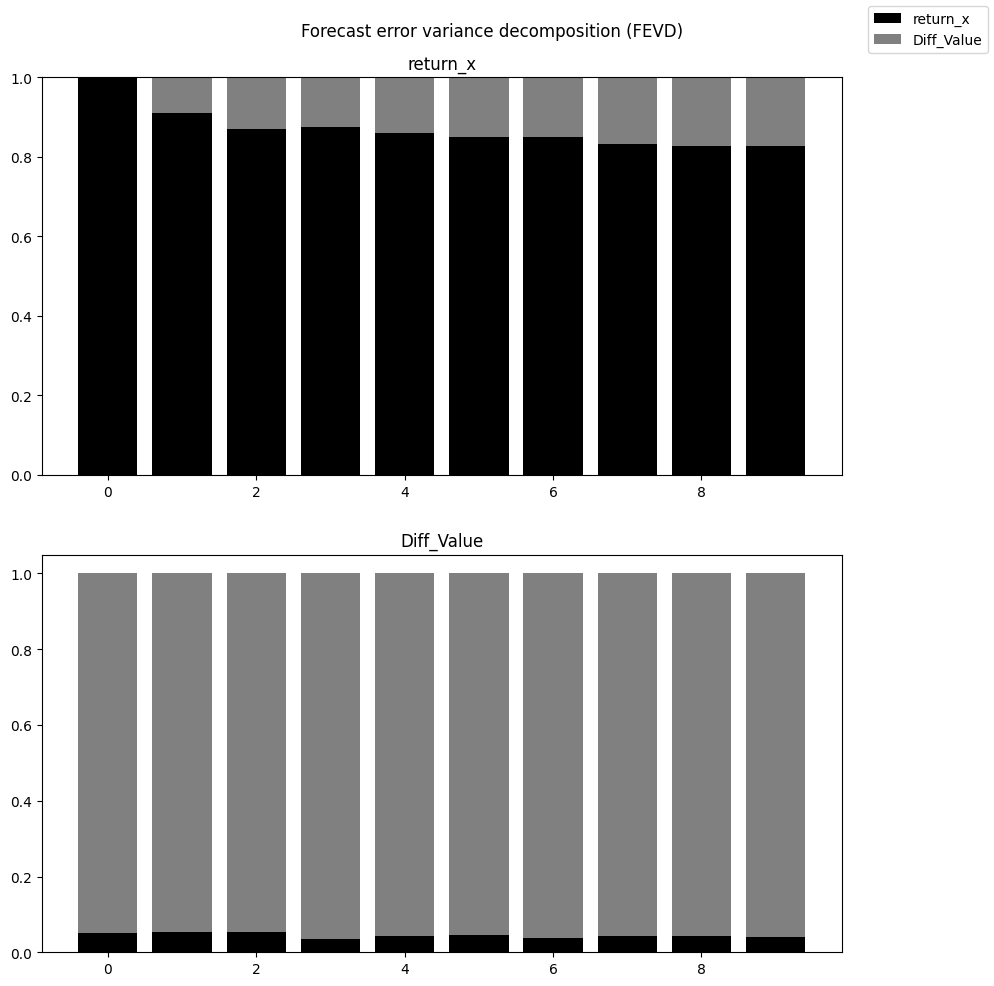

In [29]:
print(fevd.summary()) # Prints tabular percentages for each period
fevd.plot()           # Generates stacked bar plots for each variable


### In Python, Forecast Error Variance Decomposition (FEVD) is primarily performed using the statsmodels library within a Vector Autoregression (VAR) framework. FEVD helps determine how much of the forecast error variance of each variable can be explained by shocks to itself versus shocks to other variables in the system over time.

## Cointegration & VECM

In [30]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

### A VECM is required when you have multiple non-stationary time series variables that share a long-term economic or financial equilibrium (meaning they are cointegrated).
The workflow consists of three major steps: checking for stationarity, checking for cointegration via the Johansen Test, and fitting the VECM model.

In [31]:
data = df[['Close','Value']].dropna()

In [32]:
data

,Close,Value
0,28.818560,9.946
1,39.644203,12.300
2,42.283222,10.750
3,46.364693,11.480
4,48.360565,13.140
5,44.648651,11.970
6,42.198971,13.430
7,46.625744,13.730
8,48.028790,11.730
9,62.844852,12.240


In [33]:
# 2. Verify Non-Stationarity (ADF Test)
# Both variables should be non-stationary in their levels but stationary in differences
for col in data.columns:
    result = adfuller(df[col])
    print(f"ADF Statistic for {col}: {result[0]:.4f} (p-value: {result[1]:.4f})")

ADF Statistic for Close: -0.9472 (p-value: 0.7720)
ADF Statistic for Value: 1.2418 (p-value: 0.9963)


C:\Users\ftorr\AppData\Local\Temp\ipykernel_13744\3243421259.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(df[col])
C:\Users\ftorr\AppData\Local\Temp\ipykernel_13744\3243421259.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(df[col])


In [34]:
data['Value'].diff().dropna()

1      2.354
2     -1.550
3      0.730
4      1.660
5     -1.170
6      1.460
7      0.300
8     -2.000
9      0.510
10     2.130
11    -1.840
12     2.260
13     2.220
14    -2.590
15     3.820
16     0.830
17    -0.340
18     1.980
19     0.580
20    -4.640
21     1.380
22     2.680
23    -4.620
24     2.480
25     2.200
26     0.100
27     0.550
28     3.730
29    -1.560
30     2.350
31     2.750
32    -4.060
33    11.570
34     4.400
Name: Value, dtype: float64

In [35]:
data_diff = pd.DataFrame({ 'Diff_Close' : data['Close'].diff().dropna(), 'Diff_Value' : data['Value'].diff().dropna()} )

In [36]:
data_diff

,Diff_Close,Diff_Value
1,10.825644,2.354
2,2.639019,-1.550
3,4.081470,0.730
4,1.995872,1.660
5,-3.711914,-1.170
6,-2.449680,1.460
7,4.426773,0.300
8,1.403046,-2.000
9,14.816063,0.510
10,19.196354,2.130


In [37]:
# 2. Verify Non-Stationarity (ADF Test)
# Both variables should be non-stationary in their levels but stationary in differences
for col in data_diff.columns:
    result = adfuller(data_diff[col])
    print(f"ADF Statistic for {col}: {result[0]:.4f} (p-value: {result[1]:.4f})")

ADF Statistic for Diff_Close: -5.3585 (p-value: 0.0000)
ADF Statistic for Diff_Value: 0.7944 (p-value: 0.9915)


C:\Users\ftorr\AppData\Local\Temp\ipykernel_13744\3838159116.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(data_diff[col])
C:\Users\ftorr\AppData\Local\Temp\ipykernel_13744\3838159116.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(data_diff[col])


In [38]:
# 3. Johansen Cointegration Test
# det_order: -1 = no constant, 0 = constant, 1 = linear trend
# k_ar_diff: Number of lagged differences
johansen_test = coint_johansen(data, det_order=0, k_ar_diff=1)

print("\n--- Johansen Cointegration Test Results ---")
print("Trace Statistic:", johansen_test.lr1)
print("Critical Values (90%, 95%, 99%):\n", johansen_test.cvt)


--- Johansen Cointegration Test Results ---
Trace Statistic: [4.79750527 0.19850315]
Critical Values (90%, 95%, 99%):
 [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [39]:
# 4. Fit the Vector Error Correction Model (VECM)
# Assume the Johansen test indicated 1 cointegrating relationship (coint_rank=1)
model = VECM(data, k_ar_diff=1, coint_rank=1, deterministic='co')
vecm_res = model.fit()

In [40]:
# 5. Review the Results
print(vecm_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation Close
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.0749      5.721      1.586      0.113      -2.139      20.288
L1.Close       0.0732      0.171      0.427      0.669      -0.262       0.409
L1.Value       0.8736      0.751      1.163      0.245      -0.599       2.346
Det. terms outside the coint. relation & lagged endog. parameters for equation Value
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3401      1.275     -1.051      0.293      -3.838       1.158
L1.Close       0.0089      0.038      0.234      0.815      -0.066       0.084
L1.Value      -0.3452      0.167     -2.063      0.039      -0.673      -0.017
               Loading coefficients (alp

In [41]:
# 6. Forecasting future values
forecast = vecm_res.predict(steps=5)
print("\nForecasted next 5 steps:\n", forecast)


Forecasted next 5 steps:
 [[184.37608792  42.0560228 ]
 [184.31408697  44.66532339]
 [184.86908332  46.94566716]
 [184.96976106  49.4339365 ]
 [185.00672086  51.93521711]]


### The key idea behind VECM is if ​variable moves too far away from equilibrium, ​the model gradually pulls them back together. ​This adjustment mechanism is called error correction. ​That's why VECM is extremely ​powerful for financial system, ​economic indicators, market equilibrium analysis. ​Now, VAR versus VECM. ​Use VAR when variables are stationary, ​and use VECM when variables ​are non-stationary but cointegrated. 

## Multivariate LSTM — Joint Forecasting

In [42]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date_x               35 non-null     object 
 1   Close                35 non-null     float64
 2   High                 35 non-null     float64
 3   Low                  35 non-null     float64
 4   Open                 35 non-null     float64
 5   Volume               35 non-null     int64  
 6   Close_l              35 non-null     float64
 7   Close_2              35 non-null     float64
 8   Rolling_mean_3_x     35 non-null     float64
 9   Rolling_std_3_x      35 non-null     float64
 10  Spanding_mean_x      35 non-null     float64
 11  return_x             35 non-null     float64
 12  Year_x               35 non-null     int64  
 13  Month_x              35 non-null     int64  
 14  YM                   35 non-null     object 
 15  Date_y               35 non-null     objec

In [50]:
features = df[['Close',
    'Value',
    'Rolling_mean_3_x',
    'Rolling_mean_3_y']].dropna()

In [51]:
features

,Close,Value,Rolling_mean_3_x,Rolling_mean_3_y
0,28.818560,9.946,27.873226,10.998667
1,39.644203,12.300,39.114221,11.510000
2,42.283222,10.750,41.717621,11.790000
3,46.364693,11.480,46.519222,12.196667
4,48.360565,13.140,48.892605,12.846667
5,44.648651,11.970,43.659606,13.043333
6,42.198971,13.430,41.298659,12.963333
7,46.625744,13.730,47.084376,12.566667
8,48.028790,11.730,48.928852,12.780000
9,62.844852,12.240,62.262206,13.046667


In [47]:
scaler = MinMaxScaler()
scaler_data = scaler.fit_transform(features)

In [52]:
scaler_data

array([[0.        , 0.        , 0.        , 0.        ],
       [0.06096653, 0.07679259, 0.06396901, 0.01549902],
       [0.07582864, 0.02622822, 0.07878414, 0.0239861 ],
       [0.09881416, 0.05004241, 0.10610856, 0.03631257],
       [0.11005427, 0.10419521, 0.11961474, 0.05601471],
       [0.08914997, 0.06602727, 0.08983537, 0.06197587],
       [0.07535416, 0.11365564, 0.07639996, 0.05955099],
       [0.10028432, 0.12344229, 0.10932468, 0.04752763],
       [0.10818582, 0.05819795, 0.11982102, 0.05399398],
       [0.19162511, 0.07483526, 0.19569698, 0.06207691],
       [0.29973279, 0.14432048, 0.29353228, 0.08784125],
       [0.34515155, 0.08429569, 0.35392081, 0.11451492],
       [0.30403354, 0.15802179, 0.32787664, 0.13361085],
       [0.48350459, 0.23044301, 0.47528715, 0.16846849],
       [0.53578773, 0.14595159, 0.54475744, 0.18928203],
       [0.45104034, 0.27056828, 0.46555366, 0.23282882],
       [0.44424479, 0.29764468, 0.49392855, 0.25778487],
       [0.49484619, 0.28655314,

In [58]:
scaler_data[1]

array([0.06096653, 0.07679259, 0.06396901, 0.01549902])

In [59]:
X = []
y =[]

window_size  = 12

for i in range(window_size,len(scaler_data)):
    X.append(scaler_data[i-window_size:i])
    y.append(scaler_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)


(23, 12, 4)
(23, 4)
